In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, ShuffleSplit, train_test_split

### Load Dataset

In [2]:
X, y = make_moons(n_samples=10000, noise=0.4)
X_moons, X_test, y_moons, y_test = train_test_split(X, y, test_size=0.2)
X_moons

array([[ 0.79700192, -0.18510772],
       [ 0.44560872,  0.47147549],
       [ 0.77278906, -0.61301585],
       ...,
       [ 1.66542461,  0.56314159],
       [-1.51174248,  0.40230115],
       [-1.23382508, -0.20061071]], shape=(8000, 2))

In [3]:
y_moons

array([1, 0, 1, ..., 1, 0, 0], shape=(8000,))

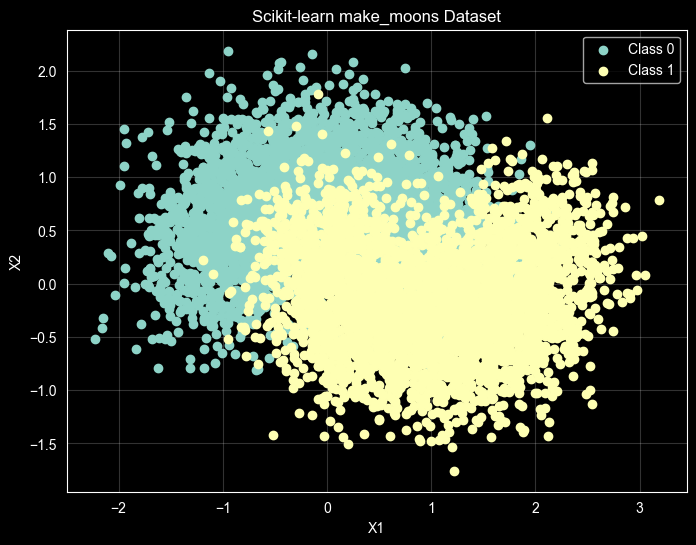

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], label="Class 0")
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], label="Class 1")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Scikit-learn make_moons Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Decision tree

In [5]:
param_grid = dict(max_leaf_nodes=[2, 5, 10, 20, 50, 100, 200, 500, 1000], min_samples_split=[2, 5, 10, 20])
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_moons, y_moons)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [6]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Test set score: {grid_search.score(X_test, y_test):.4f}")

Best parameters: {'max_leaf_nodes': 5, 'min_samples_split': 2}
Best cross-validation score: 0.8564
Test set score: 0.8575


In [7]:
best_tree = grid_search.best_estimator_
best_tree.score(X_test, y_test)

0.8575

### Random Forest

In [8]:
rs = ShuffleSplit(n_splits=1000, test_size=len(X_moons) - 100, random_state=42)
subsets = []
for train_index, _ in rs.split(X_moons):
    subsets.append((X_moons[train_index], y_moons[train_index]))
print(f"Generated {len(subsets)} subsets")
print(f"Each subset contains {len(subsets[0][0])} instances")

Generated 1000 subsets
Each subset contains 100 instances


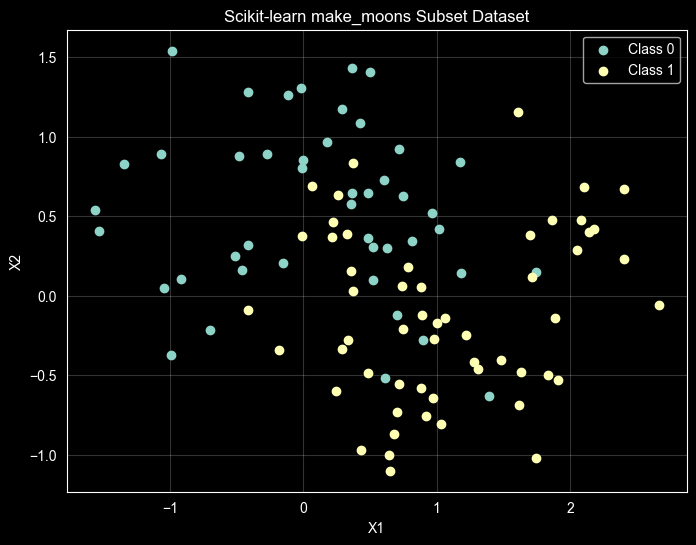

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(subsets[0][0][subsets[0][1] == 0, 0], subsets[0][0][subsets[0][1] == 0, 1], label="Class 0")
plt.scatter(subsets[0][0][subsets[0][1] == 1, 0], subsets[0][0][subsets[0][1] == 1, 1], label="Class 1")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Scikit-learn make_moons Subset Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [10]:
scores = []
for x, y in subsets:
    dt = DecisionTreeClassifier(max_leaf_nodes = 20, min_samples_split=2)
    dt.fit(x, y)
    score = dt.score(X_test, y_test)
    scores.append(score)
scores

[0.837,
 0.7945,
 0.779,
 0.8285,
 0.742,
 0.768,
 0.8195,
 0.7785,
 0.757,
 0.805,
 0.7625,
 0.7585,
 0.7795,
 0.7805,
 0.788,
 0.775,
 0.813,
 0.791,
 0.786,
 0.7895,
 0.798,
 0.7415,
 0.772,
 0.8215,
 0.798,
 0.7885,
 0.7535,
 0.759,
 0.8045,
 0.7195,
 0.8045,
 0.8015,
 0.805,
 0.8115,
 0.7745,
 0.722,
 0.793,
 0.7865,
 0.782,
 0.722,
 0.773,
 0.759,
 0.8085,
 0.798,
 0.819,
 0.7815,
 0.7715,
 0.829,
 0.8185,
 0.8125,
 0.76,
 0.748,
 0.806,
 0.728,
 0.839,
 0.8275,
 0.7965,
 0.783,
 0.8045,
 0.7565,
 0.812,
 0.8215,
 0.796,
 0.7605,
 0.804,
 0.8205,
 0.8335,
 0.781,
 0.798,
 0.7675,
 0.7945,
 0.7565,
 0.79,
 0.7835,
 0.7005,
 0.7305,
 0.8005,
 0.783,
 0.8025,
 0.797,
 0.7745,
 0.7775,
 0.784,
 0.7995,
 0.803,
 0.816,
 0.8115,
 0.81,
 0.8185,
 0.804,
 0.842,
 0.7995,
 0.809,
 0.8,
 0.796,
 0.8305,
 0.7495,
 0.7865,
 0.7785,
 0.805,
 0.7855,
 0.7975,
 0.8005,
 0.7555,
 0.7965,
 0.803,
 0.753,
 0.7805,
 0.74,
 0.759,
 0.778,
 0.7925,
 0.804,
 0.7725,
 0.741,
 0.789,
 0.806,
 0.819,
 0.

(np.float64(0.6735),
 np.float64(0.7876914999999999),
 np.float64(0.79025),
 ModeResult(mode=np.float64(0.798), count=np.int64(15)),
 np.float64(0.8515))

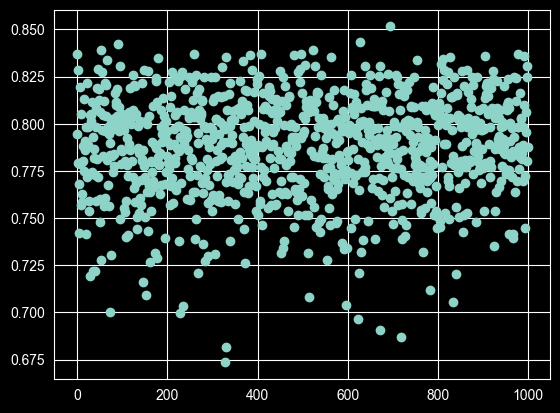

In [12]:
plt.scatter(list(range(len(scores))), scores)
min_score = np.min(scores)
average_score = np.mean(scores)
freq_score = scipy.stats.mode(scores)
median_score = np.median(scores)
max_score = np.max(scores)
min_score, average_score, median_score, freq_score, max_score